This notebook generates `Datasets/Generated/IO_Neurons.csv` file

In [1]:
from trimesh import Trimesh
import pandas as pd
import pathlib
import os
from tqdm.notebook import tqdm

os.chdir("../..")

# Sorry for this shitty path variables, It will be fixed on server soon (fix for this error: "Permission denied: '/root/.cargo/bin'")
os.environ["PATH"] = ":".join(
    p for p in os.environ["PATH"].split(":")
    if not p.startswith("/root")
)


import pymaid

catmaid_url = 'https://l1em.catmaid.virtualflybrain.org'
http_user = None
http_password = None
project_id = 1

rm = pymaid.CatmaidInstance(catmaid_url, http_user, http_password, project_id)


import warnings
import logging

warnings.filterwarnings(
    "ignore",
    message="The behavior of DataFrame concatenation with empty or all-NA entries is deprecated"
)

logging.getLogger('pymaid').setLevel(logging.WARNING)

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


In [2]:
# -------------------- get ALL neuron ids --------------------
neuron_ids = sorted(map(int, pymaid.get_skids_by_annotation('mw brain and inputs')))

len(neuron_ids)

3016

## INPUT

### Cell Types
- **sensory** — input нейроны; первичные сенсорные клетки, получающие сигнал из окружающей среды  
- **ascending** — восходящие нейроны из VNC в мозг (обратная связь от тела)  

### Annotations
- **visual** — зрение  
- **olfactory** — обоняние  
- **gustatory-external** — внешний вкус  
- **gustatory-pharyngeal** — глоточный вкус  
- **thermo-warm, thermo-cold** — температурная чувствительность  
- **noci** — ноцицепция (боль)  
- **mechano-Ch** — механорецепция (хордотональные органы)  
- **mechano-II/III** — механорецепция  
- **proprio** — проприоцепция  
- **gut** — кишечная чувствительность  
- **respiratory** — дыхательные сигналы  

---

## OUTPUT (possible)

### Cell Types
- **DN-VNC** — Descending Neurons → Ventral Nerve Cord; основные кандидаты на output, аксоны идут прямо в VNC к мотонейронам  
- **DN-SEZ** — Descending Neurons → Subesophageal Zone; управление ротовым аппаратом и глоткой  
- **RGN** — Ring Gland Neurons; нейроны с аксонами, оканчивающимися в кольцевой железе (ring gland) — главном нейроэндокринном органе личинки дрозофиллы (нейроэндокринный output — выброс гормонов, контроль роста, линьки, метаболизма, итд)

In [3]:
s2 = pd.read_csv('./Datasets/Original/s2.csv')
s3 = pd.read_csv('./Datasets/Original/s3.csv')
s4 = pd.read_csv('./Datasets/Original/s4.csv')
out = pd.read_csv('./Datasets/Original/outputs.csv', index_col=0)



# копируем нужные столбцы
left = s2[['left_id', 'celltype', 'additional_annotations']].copy()
right = s2[['right_id', 'celltype', 'additional_annotations']].copy()

# переименовываем ключ
left = left.rename(columns={'left_id': 'neuron_id'})
right = right.rename(columns={'right_id': 'neuron_id'})

# объединяем
s2_merged = pd.concat([left, right], ignore_index=True)

# убираем строки без нейрона
s2_merged = s2_merged[s2_merged['neuron_id'] != 'no pair']

# приводим тип
s2_merged['neuron_id'] = s2_merged['neuron_id'].astype(int)


# -------------------- load INPUT neurons --------------------
input_neurons = s2_merged[s2_merged['celltype'].isin(['sensory', 'ascending'])]["neuron_id"]
input_neurons = set(input_neurons)


# -------------------- load OUTPUT neurons --------------------
# # we can take it via length of an axon
# output_neurons = set(out[out['axon_output'] > 50].index.astype(int))
output_neurons = s2_merged[s2_merged['celltype'].isin(['DN-VNC', 'DN-SEZ', 'RGN'])]["neuron_id"]
output_neurons = set(output_neurons)


# -------------------- Build final table --------------------
df = pd.DataFrame({'neuron_id': neuron_ids})
df = df.merge(s2_merged, on='neuron_id', how='left')

# add IO column
IO = []

for nid in df['neuron_id']:
    if nid in input_neurons:
        IO.append('input')
    elif nid in output_neurons:
        IO.append('output')
    else:
        IO.append(None)

df['IO'] = IO

In [4]:
print(f'Input Neurons: {len(df[df["IO"] == "input"])}')
print(f'Output Neurons: {len(df[df["IO"] == "output"])}')

df

Input Neurons: 480
Output Neurons: 394


,neuron_id,celltype,additional_annotations,IO
0,29,KC,KC,None
1,37365,sensory,visual,input
2,40045,sensory,olfactory,input
3,40152,sensory,gut,input
4,677717,KC,KC,None
...,...,...,...,...
3011,21590978,NaN,NaN,None
3012,21591033,PN-somato,mechano-Ch 2nd_order PN,None
3013,21591037,pre-DN-VNC,no official annotation,None
3014,21591317,NaN,NaN,None


## Calculate DN-VNC Output Segments
Here we will use projectome to VNC as described in "The connectome of an insect brain". Briefly, it calculates the number of presynapses in each VNC segment.

In [5]:
dVNC_skids = list(df[df["celltype"]=="DN-VNC"]["neuron_id"])
len(dVNC_skids)

182

In [6]:
# Получить пресинаптические связи
links = pymaid.get_connector_links(dVNC_skids)
pre_links = links[links['relation'] == 'presynaptic_to'].copy()

# Загрузить меши сегментов
segment_names = [
    'SEZ_left', 'SEZ_right',
    'T1_left', 'T1_right',
    'T2_left', 'T2_right',
    'T3_left', 'T3_right',
    'A1_left', 'A1_right',
    'A2_left', 'A2_right',
    'A3_left', 'A3_right',
    'A4_left', 'A4_right',
    'A5_left', 'A5_right',
    'A6_left', 'A6_right',
    'A7_left', 'A7_right',
    'A8_left', 'A8_right',
]

meshes = {}
name = ""
for name in tqdm(segment_names, desc=f"Loading meshes"):
    vol = pymaid.get_volume(name)
    meshes[name] = Trimesh(vertices=vol.vertices, faces=vol.faces)

# Функция проверки точек внутри меша через ray casting
def points_in_mesh(mesh, points):
    from trimesh.ray import ray_pyembree
    try:
        rpc = ray_pyembree.RayMeshIntersector(mesh)
    except Exception:
        from trimesh.ray import ray_triangle
        rpc = ray_triangle.RayMeshIntersector(mesh)
    return mesh.contains(points)

# Основной цикл
rows = []

for skid in tqdm(dVNC_skids, desc="Calculating synapses"):
    neuron_pre = pre_links[pre_links['skeleton_id'] == skid]
    points = neuron_pre[['x', 'y', 'z']].values

    if len(points) == 0:
        for seg in segment_names:
            rows.append({
                'neuron_id': skid,
                'segment': seg,
                'synapse_count': 0
            })
        continue

    for seg_name, mesh in meshes.items():
        try:
            inside = mesh.contains(points)
            count = int(inside.sum())
        except Exception as e:
            print(f"  Ошибка {skid} / {seg_name}: {e}")
            count = 0

        rows.append({
            'neuron_id': skid,
            'segment': seg_name,
            'synapse_count': count
        })

# Собираем результат
df_long = pd.DataFrame(rows)

# Определяем dominant segment — сегмент с максимальным числом синапсов
idx = df_long.groupby('neuron_id')['synapse_count'].idxmax()
df_dominant = df_long.loc[idx][['neuron_id', 'segment']].copy()
df_dominant.columns = ['neuron_id', 'related_segment']
df_dominant = df_dominant.reset_index(drop=True)

# Широкий формат — каждый сегмент отдельная колонка
df_wide = df_long.pivot(index='neuron_id', columns='segment', values='synapse_count').fillna(0).astype(int)
df_wide.columns.name = None
df_wide = df_wide.reset_index()

# Добавляем колонку related_segment в широкий формат
df_wide = df_wide.merge(df_dominant, on='neuron_id')

df_projectome = df_wide[['neuron_id', 'related_segment'] + segment_names]

df_projectome

Fetching links:   0%|          | 0/182 [00:00<?, ?it/s]

Loading meshes:   0%|          | 0/24 [00:00<?, ?it/s]

Calculating synapses:   0%|          | 0/182 [00:00<?, ?it/s]

,neuron_id,related_segment,SEZ_left,SEZ_right,T1_left,T1_right,T2_left,T2_right,T3_left,T3_right,...,A4_left,A4_right,A5_left,A5_right,A6_left,A6_right,A7_left,A7_right,A8_left,A8_right
0,1065967,T2_left,18,0,14,0,20,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1622901,SEZ_left,28,0,7,0,20,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,1678567,SEZ_left,17,0,11,0,12,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1980134,A4_left,6,0,1,0,1,0,8,0,...,11,0,7,0,7,0,5,0,0,0
4,2669844,A2_left,0,0,0,0,4,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,19361427,T1_left,21,0,22,0,12,0,13,0,...,0,0,0,0,0,0,0,0,0,0
178,19508873,SEZ_right,0,21,0,6,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
179,20556072,SEZ_left,9,0,6,0,2,0,4,0,...,0,0,0,0,0,0,0,0,0,0
180,20911955,SEZ_left,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Add projectome segment annotations to overall annotations
mapping = df_projectome.set_index('neuron_id')['related_segment']
df['additional_annotations'] = df['additional_annotations'].where(
    ~df['neuron_id'].isin(mapping.index),
    df['neuron_id'].map(mapping)
)

# Save

In [8]:
df.to_csv("./Datasets/Generated/IO_Neurons.csv")

# BONUS!
Almost the same VNC projectome plot as in core article (fig 7B-ii)

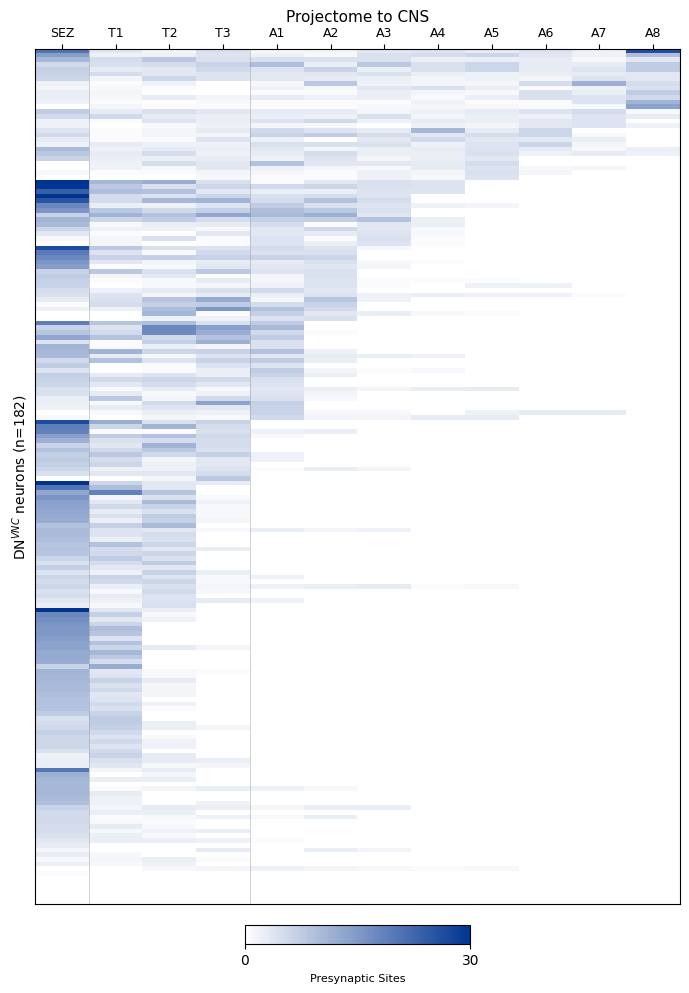

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

segment_pairs = ['SEZ', 'T1', 'T2', 'T3', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']

# Объединяем left+right попарно
matrix = pd.DataFrame(index=df_wide['neuron_id'])
for seg in segment_pairs:
    left = f'{seg}_left'
    right = f'{seg}_right'
    if left in df_wide.columns and right in df_wide.columns:
        matrix[seg] = (df_wide[left].values + df_wide[right].values) / 2
    elif left in df_wide.columns:
        matrix[seg] = df_wide[left].values
    elif right in df_wide.columns:
        matrix[seg] = df_wide[right].values

matrix = matrix.fillna(0)
matrix_capped = matrix.clip(upper=70)

# Сортировка: находим последний сегмент где синапсов > порога
threshold = 3  # минимум синапсов чтобы считать "есть проекция"

def last_segment_index(row):
    """Индекс последнего сегмента с синапсами выше порога"""
    active = np.where(row.values > threshold)[0]
    if len(active) == 0:
        return -1
    return active[-1]

def first_segment_index(row):
    """Индекс первого сегмента с синапсами выше порога"""
    active = np.where(row.values > threshold)[0]
    if len(active) == 0:
        return 99
    return active[0]

# Сортируем: сначала по последнему сегменту, потом по первому (для лесенки)
matrix_capped['_last'] = matrix_capped.apply(last_segment_index, axis=1)
matrix_capped['_first'] = matrix_capped.apply(first_segment_index, axis=1)
matrix_capped['_max_val'] = matrix_capped[segment_pairs].max(axis=1)

# Сортировка: по последнему сегменту DESC, затем по первому ASC
matrix_sorted = matrix_capped.sort_values(
    by=['_last', '_first', '_max_val'],
    ascending=[False, True, False]
)

# Убираем вспомогательные колонки
matrix_plot = matrix_sorted[segment_pairs]

# --- Рисуем ---
fig, ax = plt.subplots(figsize=(7, 11))

cmap = mcolors.LinearSegmentedColormap.from_list(
    'white_darkblue', ['#ffffff', '#013491']
)

im = ax.imshow(
    matrix_plot.values,
    aspect='auto',
    cmap=cmap,
    vmin=0,
    vmax=30,
    interpolation='nearest'
)

# Оси
ax.set_xticks(range(len(segment_pairs)))
ax.set_xticklabels(segment_pairs, fontsize=9)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_yticks([])
ax.set_ylabel(f'DN$^{{VNC}}$ neurons (n={len(matrix_plot)})', fontsize=10)

# Колорбар
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.02, shrink=0.35, aspect=12)
cbar.set_ticks([0, 30])
cbar.set_ticklabels(['0', '30'])
cbar.set_label('Presynaptic Sites', fontsize=8)

ax.set_title('Projectome to CNS', fontsize=11, pad=20)

# Вертикальные линии разделяющие группы сегментов
ax.axvline(x=0.5, color='gray', linewidth=0.5, alpha=0.5)  # SEZ | T
ax.axvline(x=3.5, color='gray', linewidth=0.5, alpha=0.5)  # T | A

plt.tight_layout()
plt.show()